now we can implement the second task: sampling

In [64]:
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt

In [65]:
def init_params(key):
    k1, k2 = jax.random.split(key)
    return {
        "w_s": jax.random.normal(k1, (1,)),
        "b_s": jnp.zeros((1,)),
        "w_t": jax.random.normal(k2, (1,)),
        "b_t": jnp.zeros((1,)),
    }

# s(z1) = tanh(w_s * z1 + b_s)
def s(params, z1):
    return jnp.tanh(params["w_s"] * z1 + params["b_s"])

# t(z1) = w_t * z1 + b_t
def t(params, z1):
    return params["w_t"] * z1 + params["b_t"]

In [66]:
def forward(params, z):
    z1, z2 = z[:, 0], z[:, 1]

    s_value = s(params, z1)
    t_value = t(params, z1)

    x1 = z1
    x2 = z2 * jnp.exp(s_value) + t_value

    log_det = s_value

    x = jnp.stack([x1, x2], axis=-1)
    return x, log_det

def inverse(params, x):
    x1, x2 = x[:, 0], x[:, 1]

    s_value = s(params, x1)
    t_value = t(params, x1)

    z1 = x1
    z2 = (x2 - t_value) * jnp.exp(-s_value)

    log_det = -s_value

    z = jnp.stack([z1, z2], axis=-1)
    return z, log_det

In [67]:
def log_pz(z):
    "Prior: normal distribution"
    return -0.5 * jnp.sum(z**2, axis=-1)

def log_q_target(x):
    """
    Gaussiana bivariata con correlazione rho.
    p(x) ∝ exp( -1/(2(1-ρ²)) · (x1² - 2ρ·x1·x2 + x2²) )
    """
    rho = 0.95          # correlazione forte, visivamente interessante
    x1, x2 = x[:, 0], x[:, 1]
    c = 1.0 / (1.0 - rho**2)
    return -0.5 * c * (x1**2 - 2*rho*x1*x2 + x2**2)

the loss function is different from the last time:
we use the reverse KL divergence

L = D_KL (p(x)||p_target(x)) = .... = E_p(z) (log p_z - log det J - log p_target)

we can t evaluate p_target, but if we can evaluate q_tartget = p_tarcet * const we can:

L = E_p(z) (log p_z - log det J - log q_target) + const

p_z we use Monte Carlo samplig to evaluate E.

In [68]:
def loss(params, key, n_samples=512):
    z = jax.random.normal(key, (n_samples, 2))
    x, log_det = forward(params, z)                     # x = f(z)
    return jnp.mean(log_pz(z) - log_det - log_q_target(x))

Training

In [69]:
@jax.jit
def step(params, key, eta):
    loss_val, grads = jax.value_and_grad(loss)(params, key)
    new_params = {k: params[k] - eta * grads[k] for k in params}
    return new_params, loss_val

def train(params, n_steps=5000, eta=1e-2, seed=0):
    key = jax.random.PRNGKey(seed)
    losses = []
    for i in range(n_steps):
        key, subkey = jax.random.split(key)   # nuova key ad ogni step!
        params, loss_val = step(params, subkey, eta)
        losses.append(float(loss_val))
        if i % 500 == 0:
            print(f"Step {i:5d} | Loss: {loss_val:.4f}")
    return params, losses

Step     0 | Loss: 5.8438
Step   500 | Loss: 1.2160
Step  1000 | Loss: 1.2047
Step  1500 | Loss: 1.2108
Step  2000 | Loss: 1.2254
Step  2500 | Loss: 1.2065
Step  3000 | Loss: 1.1988
Step  3500 | Loss: 1.2177
Step  4000 | Loss: 1.1833
Step  4500 | Loss: 1.2050


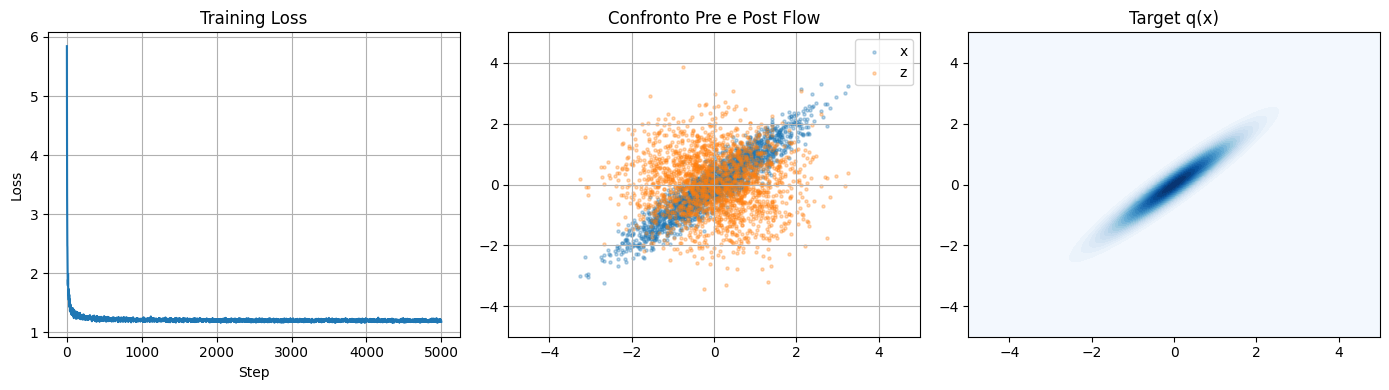

In [70]:
params = init_params(jax.random.PRNGKey(42))
params, losses = train(params, n_steps=5000, eta=1e-2)


fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# Loss curve
axes[0].plot(losses)
axes[0].set(title="Training Loss", xlabel="Step", ylabel="Loss")
axes[0].grid(True)

# Campioni generati dal flow: z ~ N(0,I)  →  x = f(z)
key = jax.random.PRNGKey(99)
z_samples = jax.random.normal(key, (2000, 2))
x_samples, _ = forward(params, z_samples)
axes[1].scatter(x_samples[:, 0], x_samples[:, 1], alpha=0.3, s=5, label="x")
axes[1].scatter(z_samples[:,0], z_samples[:,1], alpha=0.3, s=5, label="z")
axes[1].legend()
axes[1].set(title="Confronto Pre e Post Flow", xlim=(-5, 5), ylim=(-5, 5))
axes[1].grid(True)

from scipy.stats import multivariate_normal
grid = jnp.stack(jnp.meshgrid(jnp.linspace(-5,5,200), jnp.linspace(-5,5,200)), axis=-1).reshape(-1,2)
log_p = log_q_target(grid).reshape(200, 200)
axes[2].contourf(jnp.linspace(-5,5,200), jnp.linspace(-5,5,200), jnp.exp(log_p), levels=30, cmap="Blues")
axes[2].set(title="Target q(x)")

plt.tight_layout()
plt.show()


as the evaluate example this flow is changing only the x2 variable!